# Calculo de Eigenvalores para un modelo de BTC (Boundary Time Crystals) https://arxiv.org/abs/1708.05014
 Importamos librerias importantes, principalmente qutip que ya nos hace la vectorización para el Liouvilliano y para definir los operadores e incluso para realizar los productos tensoriales de manera sencilla

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

vec1= basis(5,2) 
up = basis(2,0) # (1,0)
down = basis(2,1) # (0,1)

upx = (basis(2,0) + basis(2,1)).unit() # Initial state “The system is initialised in the pure state with all spins aligned along the x-direction…”


Probando como hacer matrices de densidad y trazas parciales usando las funciones de qutip

In [4]:
# Matriz de densidad para 2 espines

psi = (1/np.sqrt(2))*(1/np.sqrt(2))*(tensor(up,down) - tensor(down,up)) 

rho = psi * psi.dag()
print(rho)

rho_0 = rho.ptrace(0) # Tr_1 rho
rho_1 = rho.ptrace(1)

print(rho_0,rho_1)  

N=10
psi = tensor([basis(2,0) for _ in range(N)])
rho = psi * psi.dag()
print(rho)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 0.    0.    0.    0.  ]
 [ 0.    0.25 -0.25  0.  ]
 [ 0.   -0.25  0.25  0.  ]
 [ 0.    0.    0.    0.  ]]
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.25 0.  ]
 [0.   0.25]] Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.25 0.  ]
 [0.   0.25]]
Quantum object: dims=[[2, 2, 2, 2, 2, 2, 2, 2, 2, 2], [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]], shape=(1024, 1024), type='oper', dtype=CSR, isherm=True
Qobj data =
[[1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


## Queremos obtener los eigenvalores del Liouvilliano
En general y en la función de qutip 

$$\mathcal{L}[\rho] = i[\rho, H] + \left( L\rho L^{\dagger} - \frac{1}{2} \{L^{\dagger}L, \rho\} \right) = \lambda \rho$$

En el modelo usan el siguiente Hamiltoniano

$$H = \omega_0 \sum_j \sigma^x_j$$
En el paper usan la siguiente expresión ya simplificada

$$\mathcal{L}[\rho] = i\omega_0[\rho, S^x] + \frac{\kappa}{S}\left( S_{-}\rho S_{+} - \frac{1}{2} \{S_{+}S_{-}, \rho\} \right)$$


In [19]:

Nb = 36 # Spin en la frontera (boundary)
S = Nb/2 # Spin total
k = 1
w_0 = 1.5*k

# Defining spin operators
Sx = jmat(S, 'x')
Sm = np.sqrt(k/S)*jmat(S, '-')
#Sp = np.sqrt(k/S)*jmat(S, '+')


H = w_0*Sx

jump_ops = [Sm]

L = liouvillian(H, jump_ops)
eigs = L.eigenenergies()

print(np.max(np.real(eigs)))

-9.348699565570497e-15


<function matplotlib.pyplot.show(close=None, block=None)>

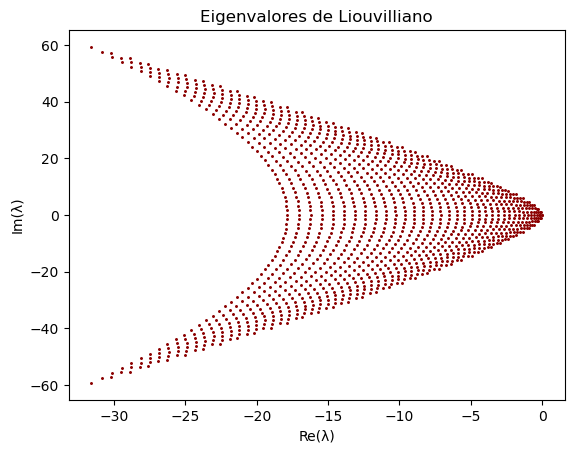

In [20]:
X = np.real(eigs)
Y = np.imag(eigs)

plt.scatter(X,Y, s=1.25, c='darkred')
plt.xlabel("Re(λ)")
plt.ylabel("Im(λ)")
plt.title("Eigenvalores de Liouvilliano")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

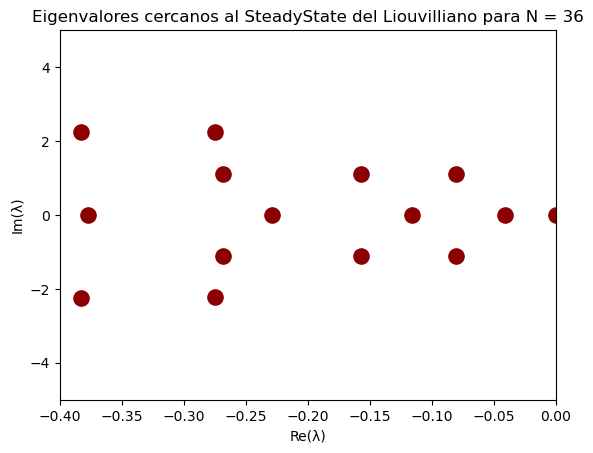

In [21]:
plt.scatter(X,Y, s=120, c='darkred')
plt.title("Eigenvalores cercanos al SteadyState del Liouvilliano para N = 36")
plt.xlabel("Re(λ)")
plt.ylabel("Im(λ)")
plt.xlim(-0.4,0)
plt.ylim(-5,5)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

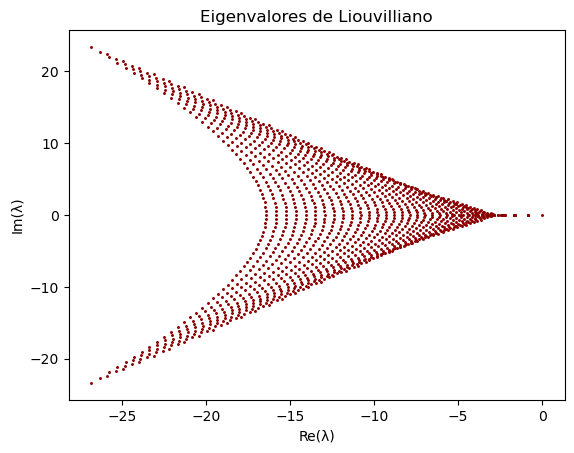

In [22]:
k = 1
w_0 = 0.5*k
# Defining spin operators
Sx = jmat(S, 'x')
Sm = np.sqrt(k/S)*jmat(S, '-')
#Sp = np.sqrt(k/S)*jmat(S, '+')


H = w_0*Sx

jump_ops = [Sm]

L = liouvillian(H, jump_ops)
eigs = L.eigenenergies()

X = np.real(eigs)
Y = np.imag(eigs)

plt.scatter(X,Y, s=1.25, c='darkred')
plt.xlabel("Re(λ)")
plt.ylabel("Im(λ)")
plt.title("Eigenvalores de Liouvilliano")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

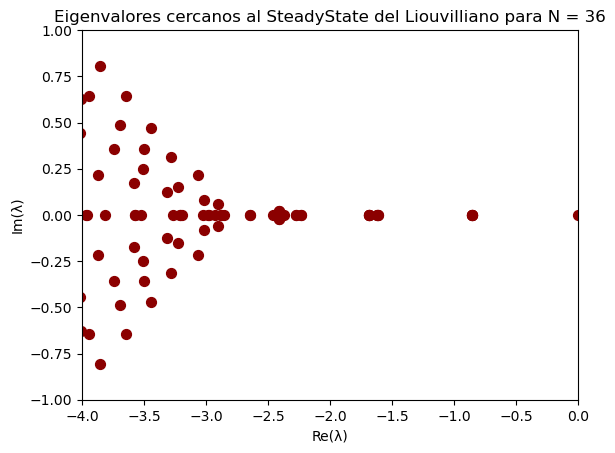

In [23]:
plt.scatter(X,Y, s=50, c='darkred')
plt.title("Eigenvalores cercanos al SteadyState del Liouvilliano para N = 36")
plt.xlabel("Re(λ)")
plt.ylabel("Im(λ)")
plt.xlim(-4,0)
plt.ylim(-1,1)
plt.show